In [1]:
# ======================================================
# STEP 1 : Import Required Libraries
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [2]:
# ======================================================
# STEP 2 : Load Dataset
# ======================================================

fake = pd.read_csv("fake.csv")
true = pd.read_csv("true.csv")

In [3]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
print("Fake Dataset Shape :", fake.shape)
print("True Dataset Shape :", true.shape)

Fake Dataset Shape : (23481, 4)
True Dataset Shape : (21417, 4)


In [6]:
print(fake.columns)
print(true.columns)

Index(['title', 'text', 'subject', 'date'], dtype='object')
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [7]:
print(fake.isnull().sum())

title      0
text       0
subject    0
date       0
dtype: int64


In [8]:
print(true.isnull().sum())

title      0
text       0
subject    0
date       0
dtype: int64


In [9]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [10]:
true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [11]:
fake["label"] = 0
true["label"] = 1

In [12]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [13]:
true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [14]:
# ======================================================
# STEP 12 : Merge Both Datasets
# ======================================================

data = pd.concat([fake, true], axis=0)

In [15]:
# ======================================================
# STEP 13 : Check Dataset Shape
# ======================================================

print("Combined Dataset Shape:", data.shape)

Combined Dataset Shape: (44898, 5)


In [16]:
# ======================================================
# STEP 14 : Shuffle Dataset
# ======================================================

data = data.sample(frac=1, random_state=42)
data.reset_index(drop=True, inplace=True)

In [17]:
# ======================================================
# STEP 15 : Display Dataset
# ======================================================

data.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [18]:
# ======================================================
# STEP 16 : Check Missing Values
# ======================================================

print(data.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [19]:
# ======================================================
# STEP 17 : Display Sample News Text
# ======================================================

data["text"].head()

0    21st Century Wire says Ben Stein, reputable pr...
1    WASHINGTON (Reuters) - U.S. President Donald T...
2    (Reuters) - Puerto Rico Governor Ricardo Rosse...
3    On Monday, Donald Trump once again embarrassed...
4    GLASGOW, Scotland (Reuters) - Most U.S. presid...
Name: text, dtype: object

In [20]:
# ======================================================
# STEP 18 : Create Text Cleaning Function
# ======================================================

import re
import string

def clean_text(text):
    text = str(text)
    text = text.lower()                         # Convert to lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'<.*?>', '', text)           # Remove HTML tags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # Remove punctuation
    text = re.sub(r'\d+', '', text)             # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()    # Remove extra spaces
    return text

In [21]:
# ======================================================
# STEP 19 : Clean News Text
# ======================================================

data["text"] = data["text"].apply(clean_text)

In [22]:
# ======================================================
# STEP 20 : Display Cleaned Text
# ======================================================

data["text"].head()

0    st century wire says ben stein reputable profe...
1    washington reuters us president donald trump r...
2    reuters puerto rico governor ricardo rossello ...
3    on monday donald trump once again embarrassed ...
4    glasgow scotland reuters most us presidential ...
Name: text, dtype: object

In [23]:
# ======================================================
# STEP 21 : Download Stopwords
# ======================================================

import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [24]:
# ======================================================
# STEP 22 : Remove Stopwords
# ======================================================

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

data["text"] = data["text"].apply(remove_stopwords)

In [25]:
# ======================================================
# STEP 23 : Display Final Cleaned Text
# ======================================================

data["text"].head()

0    st century wire says ben stein reputable profe...
1    washington reuters us president donald trump r...
2    reuters puerto rico governor ricardo rossello ...
3    monday donald trump embarrassed country accide...
4    glasgow scotland reuters us presidential candi...
Name: text, dtype: object

In [29]:
# ======================================================
# STEP 24 : Separate Features and Target
# ======================================================

X = data["text"]
y = data["label"]

In [27]:
# ======================================================
# STEP 25 : TF-IDF Vectorization
# ======================================================

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

In [28]:
# ======================================================
# STEP 26 : Check TF-IDF Shape
# ======================================================

print("Shape of X:", X.shape)

Shape of X: (44898, 5000)


In [30]:
# ======================================================
# STEP 27 : Train-Test Split
# ======================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [32]:
# ======================================================
# STEP 28 : Check Training and Testing Data
# ======================================================

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (35918,)
Testing Data : (8980,)


In [34]:
# ======================================================
# STEP 29 : Logistic Regression
# ======================================================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

ValueError: could not convert string to float: 'tune alternate current radio network acr another live broadcast boiler room starting pm pst pm est every wednesday join us uncensored uninterruptible talk radio custommade barfly philosophers misguided moralists masochists street corner evangelists mediamaniacs savants political animals otherwise lovable rascalsjoin acr hosts hesher spore along andy nowicki alt right blogspot acrwire contributor randy j stewart howe broadcast going rails cuffs listeners hearing us go around boiler room myriad topics tonight including relief booths city sarah palin endorsement donald trump whether hope political system reported sexual assaults cologne oregon standoff el chapo owning fast furious weapons want participate bring something interesting throw boiler join us alternate current radio chat roomboiler room polictally correct zone live acr player show goes live pm pstthis week topics'

In [35]:
# ======================================================
# STEP 28 : Check Training and Testing Data
# ======================================================

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (35918,)
Testing Data : (8980,)


In [38]:
# ======================================================
# STEP 27 : Train-Test Split
# ======================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [39]:
# ======================================================
# STEP 28 : Check Training and Testing Data
# ======================================================

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (35918,)
Testing Data : (8980,)


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [41]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (35918,)
X_test : (8980,)
y_train: (35918,)
y_test : (8980,)


In [42]:
print(type(X))
print(type(X_train))
print(X.shape)
print(X_train.shape)

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
(44898,)
(35918,)


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data["text"])

In [44]:
data["text"]

0        st century wire says ben stein reputable profe...
1        washington reuters us president donald trump r...
2        reuters puerto rico governor ricardo rossello ...
3        monday donald trump embarrassed country accide...
4        glasgow scotland reuters us presidential candi...
                               ...                        
44893                                                     
44894    londontokyo reuters british prime minister the...
44895    berlin reuters chancellor angela merkel said g...
44896    jesus fcking christ president moron satisfied ...
44897    toast bigger trouble thought much whole thing ...
Name: text, Length: 44898, dtype: object

In [45]:
print(type(X))
print(X.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(44898, 5000)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [47]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (35918, 5000)
X_test : (8980, 5000)
y_train: (35918,)
y_test : (8980,)


In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(data["text"])

In [50]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [51]:
lr_predictions = lr_model.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9868596881959911


In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [54]:
# ======================================================
# STEP 33 : Train KNN Model
# ======================================================

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [55]:
# ======================================================
# STEP 34 : Predict Using KNN
# ======================================================

knn_predictions = knn_model.predict(X_test)

In [56]:
# ======================================================
# STEP 35 : Evaluate KNN
# ======================================================

from sklearn.metrics import accuracy_score, classification_report

knn_accuracy = accuracy_score(y_test, knn_predictions)

print("KNN Accuracy:", knn_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, knn_predictions))

KNN Accuracy: 0.7022271714922049

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.97      0.77      4710
           1       0.92      0.41      0.57      4270

    accuracy                           0.70      8980
   macro avg       0.78      0.69      0.67      8980
weighted avg       0.78      0.70      0.67      8980



In [57]:
# ======================================================
# STEP 36 : Train Random Forest
# ======================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
# ======================================================
# STEP 37 : Predict Using Random Forest
# ======================================================

rf_predictions = rf_model.predict(X_test)

In [59]:
# ======================================================
# STEP 38 : Evaluate Random Forest
# ======================================================

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.9975501113585746

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4710
           1       1.00      1.00      1.00      4270

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [60]:
# ======================================================
# STEP 39 : Train Neural Network
# ======================================================

from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)

nn_model.fit(X_train, y_train)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,42


In [61]:
# ======================================================
# STEP 40 : Predict Using Neural Network
# ======================================================

nn_predictions = nn_model.predict(X_test)

In [62]:
# ======================================================
# STEP 41 : Evaluate Neural Network
# ======================================================

nn_accuracy = accuracy_score(y_test, nn_predictions)

print("Neural Network Accuracy:", nn_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, nn_predictions))

Neural Network Accuracy: 0.9913140311804008

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4710
           1       0.99      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [63]:
# ======================================================
# STEP 42 : Compare Model Accuracy
# ======================================================

import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest",
        "Neural Network"
    ],
    "Accuracy": [
        lr_accuracy,
        knn_accuracy,
        rf_accuracy,
        nn_accuracy
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.986860
1                  KNN  0.702227
2        Random Forest  0.997550
3       Neural Network  0.991314


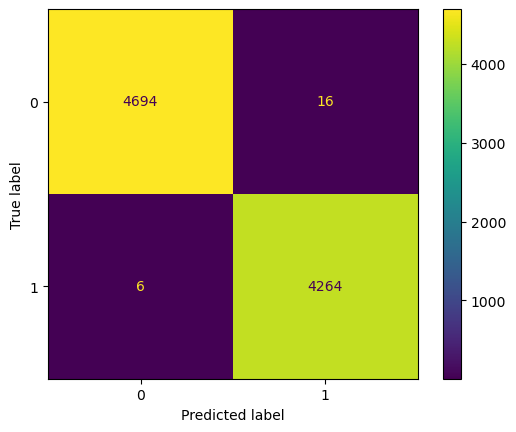

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

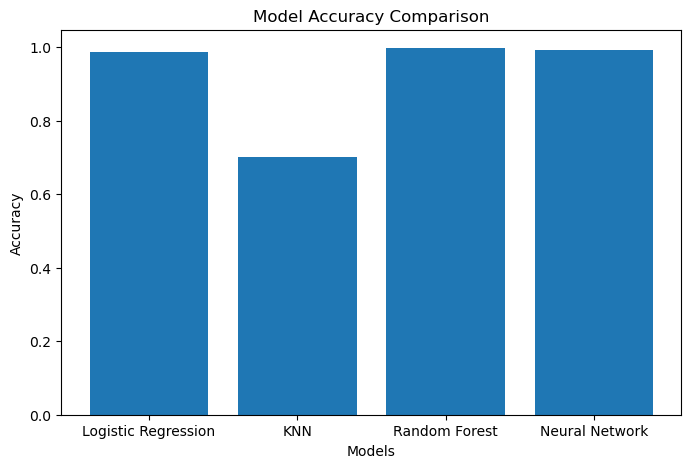

In [65]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Model Accuracy Comparison")

plt.show()

In [66]:
news = ["The president visited India for an official meeting."]

news_vector = vectorizer.transform(news)

prediction = rf_model.predict(news_vector)

if prediction[0] == 0:
    print("Fake News")
else:
    print("True News")

Fake News


In [67]:
# Enter any news text here
news = "The president visited India and announced a new education policy."

# Convert text into TF-IDF features
news_vector = vectorizer.transform([news])

# Predict using the best model (Random Forest)
prediction = rf_model.predict(news_vector)

# Display result
if prediction[0] == 1:
    print("Prediction: REAL NEWS")
else:
    print("Prediction: FAKE NEWS")

Prediction: FAKE NEWS


In [69]:
news = input("Enter News: ")

news_vector = vectorizer.transform([news])
prediction = rf_model.predict(news_vector)

if prediction[0] == 1:
    print("Prediction: REAL NEWS")
else:
    print("Prediction: FAKE NEWS")

Enter News:  news = "India won the ICC Cricket World Cup."


Prediction: FAKE NEWS


In [70]:
while True:
    news = input("Enter News (or type 'exit' to stop): ")

    if news.lower() == "exit":
        break

    news_vector = vectorizer.transform([news])
    prediction = rf_model.predict(news_vector)

    if prediction[0] == 1:
        print("Prediction: REAL NEWS\n")
    else:
        print("Prediction: FAKE NEWS\n")
        

Enter News (or type 'exit' to stop):  "The moon is made entirely of chocolate."


Prediction: FAKE NEWS



Enter News (or type 'exit' to stop):  "NASA launched a new satellite to study climate change"


Prediction: FAKE NEWS



Enter News (or type 'exit' to stop):  The Indian government announced a new education policy


Prediction: FAKE NEWS



Enter News (or type 'exit' to stop):  


Prediction: FAKE NEWS



Enter News (or type 'exit' to stop):  exit


In [71]:
print(data["label"].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [72]:
while True:
    news = input("Enter News (or type 'exit' to stop): ")

    if news.lower() == "exit":
        break

    news_vector = vectorizer.transform([news])
    prediction = rf_model.predict(news_vector)

    if prediction[0] == 1:
        print("Prediction: REAL NEWS\n")
    else:
        print("Prediction: FAKE NEWS\n")

Enter News (or type 'exit' to stop):  WASHINGTON (Reuters) - The U.S. Senate approved the tax reform bill after weeks of debate.


Prediction: REAL NEWS



Enter News (or type 'exit' to stop):  NEW YORK (Reuters) - Global stock markets rose after investors reacted positively to economic data.


Prediction: REAL NEWS



Enter News (or type 'exit' to stop):  The moon is made entirely of chocolate.


Prediction: FAKE NEWS



Enter News (or type 'exit' to stop):  Aliens officially became members of the United Nations.


Prediction: FAKE NEWS



Enter News (or type 'exit' to stop):  Hi its i here


Prediction: FAKE NEWS



Enter News (or type 'exit' to stop):  good morning everyone i successfully completed the fake news detection project 


Prediction: FAKE NEWS



Enter News (or type 'exit' to stop):  Done


Prediction: FAKE NEWS



Enter News (or type 'exit' to stop):  exit
